Loading data for predictive modeling...
Loaded 500000 records

Preparing features for prediction...
Training data: 14285 records

Training Random Forest model...
Random Forest - MSE: 34326.27, MAE: 8.00, R2: -0.1876

Training Gradient Boosting model...
Gradient Boosting - MSE: 45188.47, MAE: 8.91, R2: -0.5634

Analyzing high-risk patterns...

Saved: crash_prediction_model.png

=== CRASH PREDICTION INSIGHTS ===

High Risk Threshold: 4 crashes
High Risk Hosts: 1946 (13.6%)

High Risk Profile (90th percentile):
  avg_processor_time: 18.51 (vs 18.43, +0.4%)
  max_cpu_usage: 30.59 (vs 30.27, +1.1%)
  avg_memory_utilization: 73.56 (vs 72.27, +1.8%)
  max_memory_usage: 84.70 (vs 83.67, +1.2%)
  avg_battery_health: 80.47 (vs 78.55, +2.4%)
  cpu_count: 3706.38 (vs 3350.85, +10.6%)
  memory_size_gb: 16.23 (vs 16.38, -0.9%)
  avg_cpu_temp: 63.66 (vs 63.01, +1.0%)
  avg_boot_time: 16.78 (vs 17.51, -4.2%)
  p90_boot_time: 20.94 (vs 26.17, -20.0%)
  uptime_days: 6.48 (vs 7.22, -10.2%)

Top 3 Predict

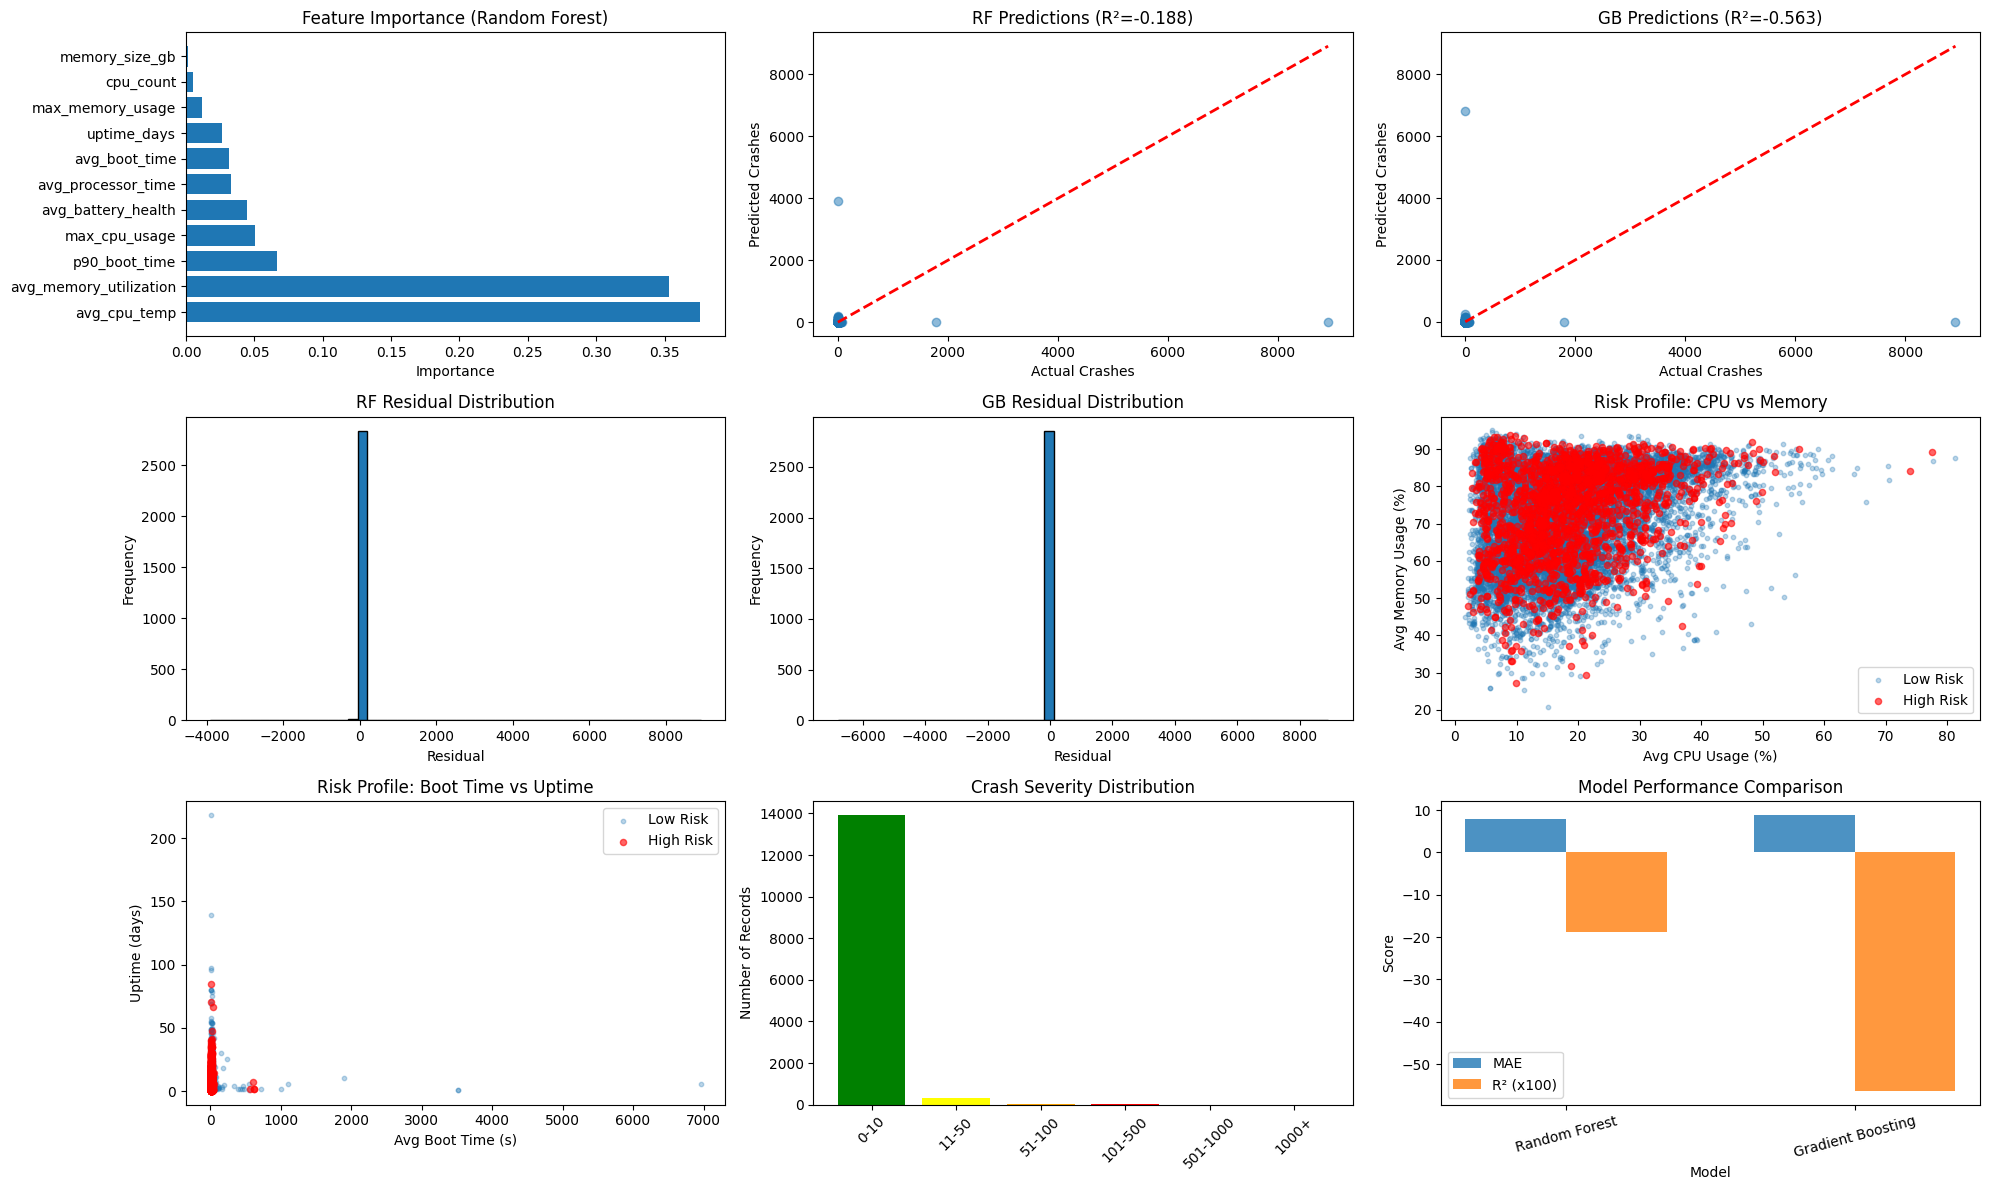

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import gzip
import warnings
warnings.filterwarnings('ignore')

print("Loading data for predictive modeling...")
columns = [
    'karl_id', 'host_name', 'model_name', 'hardware_make', 'karl_last_seen',
    'auth_username', 'serial_number', 'group_id', 'tenant_id', 'platform',
    'metric_category', 'measure_name', 'time', 'p90_processor_time',
    'avg_processor_time', 'max_cpu_usage', 'p90_memory_utilization',
    'avg_memory_utilization', 'max_memory_usage', 'p10_battery_health',
    'avg_battery_health', 'cpu_count', 'memory_count', 'memory_size_gb',
    'driver_vendor', 'os', 'wifi_mac_add', 'driver_version', 'driver_date',
    'os_version', 'driver', 'agent_id', 'performance_status', 'device_status',
    'max_battery_temperature', 'avg_battery_temperature', 'p90_battery_temperature',
    'avg_cpu_temp', 'p90_cpu_temp', 'avg_battery_discharge', 'p90_battery_discharge',
    'avg_boot_time', 'p90_boot_time', 'uptime_days', 'total_app_crash'
]

chunk_size = 100000
sample_data = []
with gzip.open('000.gz', 'rt') as f:
    for i, chunk in enumerate(pd.read_csv(f, sep='|', names=columns, chunksize=chunk_size)):
        sample_data.append(chunk)
        if i >= 4:
            break

df = pd.concat(sample_data, ignore_index=True)

numeric_cols = [
    'p90_processor_time', 'avg_processor_time', 'max_cpu_usage',
    'p90_memory_utilization', 'avg_memory_utilization', 'max_memory_usage',
    'p10_battery_health', 'avg_battery_health', 'cpu_count', 'memory_count',
    'memory_size_gb', 'max_battery_temperature', 'avg_battery_temperature',
    'p90_battery_temperature', 'avg_cpu_temp', 'p90_cpu_temp',
    'avg_battery_discharge', 'p90_battery_discharge', 'avg_boot_time',
    'p90_boot_time', 'uptime_days', 'total_app_crash'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['time'] = pd.to_datetime(df['time'], errors='coerce')

print(f"Loaded {len(df)} records")

print("\nPreparing features for prediction...")
feature_cols = [
    'avg_processor_time', 'max_cpu_usage', 'avg_memory_utilization',
    'max_memory_usage', 'avg_battery_health', 'cpu_count', 'memory_size_gb',
    'avg_cpu_temp', 'avg_boot_time', 'p90_boot_time', 'uptime_days'
]

model_df = df[feature_cols + ['total_app_crash', 'host_name']].dropna()
model_df = model_df[model_df['total_app_crash'] > 0]

print(f"Training data: {len(model_df)} records")

X = model_df[feature_cols]
y = model_df['total_app_crash']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Random Forest model...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}, R2: {rf_r2:.4f}")

print("\nTraining Gradient Boosting model...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)
# y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

# print("\nRandom Forest Performance:")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")
# print(classification_report(y_test, y_pred_rf, digits=3))

print(f"Gradient Boosting - MSE: {gb_mse:.2f}, MAE: {gb_mae:.2f}, R2: {gb_r2:.4f}")

fig = plt.figure(figsize=(20, 12))

plt.subplot(3, 3, 1)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')

plt.subplot(3, 3, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Crashes')
plt.ylabel('Predicted Crashes')
plt.title(f'RF Predictions (R²={rf_r2:.3f})')

plt.subplot(3, 3, 3)
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Crashes')
plt.ylabel('Predicted Crashes')
plt.title(f'GB Predictions (R²={gb_r2:.3f})')

plt.subplot(3, 3, 4)
residuals_rf = y_test - y_pred_rf
plt.hist(residuals_rf, bins=50, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('RF Residual Distribution')

plt.subplot(3, 3, 5)
residuals_gb = y_test - y_pred_gb
plt.hist(residuals_gb, bins=50, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('GB Residual Distribution')

print("\nAnalyzing high-risk patterns...")
high_risk_threshold = y.quantile(0.9)
model_df['high_risk'] = (model_df['total_app_crash'] >= high_risk_threshold).astype(int)

plt.subplot(3, 3, 6)
high_risk_data = model_df[model_df['high_risk'] == 1]
low_risk_data = model_df[model_df['high_risk'] == 0]
plt.scatter(low_risk_data['avg_processor_time'], low_risk_data['avg_memory_utilization'], 
            alpha=0.3, label='Low Risk', s=10)
plt.scatter(high_risk_data['avg_processor_time'], high_risk_data['avg_memory_utilization'], 
            alpha=0.6, label='High Risk', s=20, color='red')
plt.xlabel('Avg CPU Usage (%)')
plt.ylabel('Avg Memory Usage (%)')
plt.title('Risk Profile: CPU vs Memory')
plt.legend()

plt.subplot(3, 3, 7)
plt.scatter(low_risk_data['avg_boot_time'], low_risk_data['uptime_days'], 
            alpha=0.3, label='Low Risk', s=10)
plt.scatter(high_risk_data['avg_boot_time'], high_risk_data['uptime_days'], 
            alpha=0.6, label='High Risk', s=20, color='red')
plt.xlabel('Avg Boot Time (s)')
plt.ylabel('Uptime (days)')
plt.title('Risk Profile: Boot Time vs Uptime')
plt.legend()

plt.subplot(3, 3, 8)
crash_bins = [0, 10, 50, 100, 500, 1000, float('inf')]
crash_labels = ['0-10', '11-50', '51-100', '101-500', '501-1000', '1000+']
model_df['crash_category'] = pd.cut(model_df['total_app_crash'], bins=crash_bins, labels=crash_labels)
crash_cat_dist = model_df['crash_category'].value_counts().sort_index()
colors = ['green', 'yellow', 'orange', 'red', 'darkred', 'black']
plt.bar(range(len(crash_cat_dist)), crash_cat_dist.values, color=colors[:len(crash_cat_dist)])
plt.xticks(range(len(crash_cat_dist)), crash_cat_dist.index, rotation=45)
plt.ylabel('Number of Records')
plt.title('Crash Severity Distribution')

plt.subplot(3, 3, 9)
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'MAE': [rf_mae, gb_mae],
    'R²': [rf_r2, gb_r2]
})
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df['MAE'], width, label='MAE', alpha=0.8)
plt.bar(x + width/2, comparison_df['R²'] * 100, width, label='R² (x100)', alpha=0.8)
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, comparison_df['Model'], rotation=15)
plt.legend()

plt.tight_layout()
plt.savefig('crash_prediction_model.png', dpi=300, bbox_inches='tight')
print("\nSaved: crash_prediction_model.png")

print("\n=== CRASH PREDICTION INSIGHTS ===")
print(f"\nHigh Risk Threshold: {high_risk_threshold:.0f} crashes")
print(f"High Risk Hosts: {(model_df['high_risk'] == 1).sum()} ({(model_df['high_risk'] == 1).sum() / len(model_df) * 100:.1f}%)")

print("\nHigh Risk Profile (90th percentile):")
high_risk_profile = model_df[model_df['high_risk'] == 1][feature_cols].mean()
low_risk_profile = model_df[model_df['high_risk'] == 0][feature_cols].mean()

for col in feature_cols:
    diff = ((high_risk_profile[col] - low_risk_profile[col]) / low_risk_profile[col] * 100)
    print(f"  {col}: {high_risk_profile[col]:.2f} (vs {low_risk_profile[col]:.2f}, {diff:+.1f}%)")

print("\nTop 3 Predictive Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("\n=== RECOMMENDATIONS ===")
print("1. Monitor hosts with:")
print(f"   - CPU usage > {high_risk_profile['avg_processor_time']:.1f}%")
print(f"   - Memory usage > {high_risk_profile['avg_memory_utilization']:.1f}%")
print(f"   - Boot time > {high_risk_profile['avg_boot_time']:.1f}s")
print("\n2. Implement proactive maintenance for high-risk hosts")
print("3. Consider hardware upgrades for persistent high-crash systems")
print("4. Investigate software conflicts on hosts with sudden crash spikes")

print("\nAnalysis complete!")

y_pred_rf_category = (y_pred_rf >= high_risk_threshold).astype(int)
y_pred_gb_category = (y_pred_gb >= high_risk_threshold).astype(int)

rf_accuracy = accuracy_score((y_test >= high_risk_threshold).astype(int), y_pred_rf_category)
gb_accuracy = accuracy_score((y_test >= high_risk_threshold).astype(int), y_pred_gb_category)

print(f"Random Forest - Accuracy (high risk detection): {rf_accuracy:.3f}")
print(f"Gradient Boosting - Accuracy (high risk detection): {gb_accuracy:.3f}")
